In [1]:
import os
import re

from glob import glob
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from glob import glob

from matplotlib.lines import Line2D

plt.rcParams.update({'font.size': 10})

In [2]:
def calculate_temp_variation(coefficients, model_name):

    bsplines = pd.read_csv('data/temperature_bsplines.csv')

    temp_coef = []
    for i, coefs in coefficients.iterrows():

        temp = np.linspace(10, 35, 200)

        if model_name == 'Climate(lag 1) + Year|region + Month|region':
            lag1_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag1{i}'] for i in range(1, 5))

            temp_variation = pd.DataFrame({
                'coef': lag1_terms,
                'temp': temp
            })
        elif model_name == 'Climate(lag 1-3) + Year|region + Month|region':
            lag1_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag1{i}'] for i in range(1, 5))
            lag2_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag2{i}'] for i in range(1, 5))
            lag3_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag3{i}'] for i in range(1, 5))

            temp_variation = pd.DataFrame({
                'coef': lag1_terms + lag2_terms + lag3_terms,
                'temp': temp
            })
        elif model_name in ['Year + Month + P(Climate)']:
            degree1_terms = sum(temp * coefs.loc[f'mean_2m_air_temp_degree1_lag{i}'] for i in range(1, 4))
            degree2_terms = sum((temp ** 2) * coefs.loc[f'mean_2m_air_temp_degree2_lag{i}'] for i in range(1, 4))
            degree3_terms = sum((temp ** 3) * coefs.loc[f'mean_2m_air_temp_degree3_lag{i}'] for i in range(1, 4))

            temp_variation = pd.DataFrame({
                'coef': degree1_terms + degree2_terms + degree3_terms,
                'temp': temp
            })
        else:
            lag1_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag1{i}'] for i in range(1, 5))
            lag2_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag2{i}'] for i in range(1, 5))
            lag3_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag3{i}'] for i in range(1, 5))
            lag4_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag4{i}'] for i in range(1, 5))
            lag5_terms = sum(bsplines[f'bs_{i}'] * coefs.loc[f'temp_bs_lag5{i}'] for i in range(1, 5))

            temp_variation = pd.DataFrame({
                'coef': lag1_terms + lag2_terms + lag3_terms + lag4_terms + lag5_terms,
                'temp': temp
            })

        temp_variation['model'] = i
        temp_coef.append(temp_variation)

    temp_coef = pd.concat(temp_coef)
    temp_coef_variation = temp_coef.groupby('model').apply(lambda x: x.set_index('temp')['coef'].diff()).reset_index().transpose()
    temp_coef_variation = temp_coef_variation.drop('model')

    quantiles = temp_coef_variation.quantile([0.025, 0.5, 0.975], axis=1).transpose().reset_index()
    quantiles['temp'] = quantiles['temp'].astype(float)

    return quantiles


In [3]:
df = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv')

df['mean_2m_air_temp_degree1'].quantile(0.01), df['mean_2m_air_temp_degree1'].quantile(0.99)

/tmp/ipykernel_753/1429109949.py:1: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv')


(np.float64(13.084776427240962), np.float64(29.958228049217784))

/tmp/ipykernel_753/3638686658.py:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp_coef_variation = temp_coef.groupby('model').apply(lambda x: x.set_index('temp')['coef'].diff()).reset_index().transpose()
/tmp/ipykernel_753/3638686658.py:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp_coef_variation = temp_coef.groupby('model').apply(lambda x: x.set_index('temp')['coef'].diff()).reset_index().transpose()


/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/*_Climate_lag_1_5/*_Climate_lag_1_5_fe_samples_temp.csv
['/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/01_Climate_lag_1_5/01_Climate_lag_1_5_fe_samples_temp.csv']
Climate(lag 1-5)
/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/01_Climate_lag_1_5/01_Climate_lag_1_5_fe_samples_temp.csv
      temp_bs_lag11  temp_bs_lag12  temp_bs_lag13  temp_bs_lag14  \
0         -7.245067       1.432370       1.190911      -5.390283   
1         -7.263592       1.419561       1.189432      -5.443961   
2         -7.272629       1.398201       1.170348      -5.460821   
3         -7.210027       1.468216       1.238471      -5.364755   
4         -7.228926       1.433604       1.215699      -5.389925   
...             ...            ...            ...            ...   
1995      -7.315358       1.382625       1.139484      -5.457927   
1996      -7.2

/tmp/ipykernel_753/3638686658.py:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp_coef_variation = temp_coef.groupby('model').apply(lambda x: x.set_index('temp')['coef'].diff()).reset_index().transpose()
/tmp/ipykernel_753/1074456185.py:135: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataframe_mapper[model])


/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/*_Climate_lag_1_5_Year_region/*_Climate_lag_1_5_Year_region_fe_samples_temp.csv
['/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/02_Climate_lag_1_5_Year_region/02_Climate_lag_1_5_Year_region_fe_samples_temp.csv']
Climate(lag 1-5) + Year|region
/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/02_Climate_lag_1_5_Year_region/02_Climate_lag_1_5_Year_region_fe_samples_temp.csv
      temp_bs_lag11  temp_bs_lag12  temp_bs_lag13  temp_bs_lag14  \
0         -5.751467       1.526589       0.657565      -4.612514   
1         -5.730651       1.539770       0.679444      -4.647748   
2         -5.780189       1.516247       0.640439      -4.624076   
3         -5.780800       1.513514       0.631388      -4.653965   
4         -5.783542       1.514033       0.631556      -4.676305   
...             ...            ...            ...            ...

/tmp/ipykernel_753/3638686658.py:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp_coef_variation = temp_coef.groupby('model').apply(lambda x: x.set_index('temp')['coef'].diff()).reset_index().transpose()
/tmp/ipykernel_753/1074456185.py:135: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataframe_mapper[model])


...

/tmp/ipykernel_753/3638686658.py:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp_coef_variation = temp_coef.groupby('model').apply(lambda x: x.set_index('temp')['coef'].diff()).reset_index().transpose()
/tmp/ipykernel_753/1074456185.py:135: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataframe_mapper[model])


/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/*_Climate_lag_1_5_Year_region_Month_region_Brazil_Mexico/*_Climate_lag_1_5_Year_region_Month_region_Brazil_Mexico_fe_samples_temp.csv
['/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/mexico_01_Climate_lag_1_5_Year_region_Month_region_Brazil_Mexico/01_Climate_lag_1_5_Year_region_Month_region_Brazil_Mexico_fe_samples_temp.csv']
Climate(lag 1-5) + Year|region + Month|region (Brazil + Mexico)
/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/mexico_01_Climate_lag_1_5_Year_region_Month_region_Brazil_Mexico/01_Climate_lag_1_5_Year_region_Month_region_Brazil_Mexico_fe_samples_temp.csv
      temp_bs_lag11  temp_bs_lag12  temp_bs_lag13  temp_bs_lag14  \
0         -7.883541      -1.002949      -4.924204      -6.943090   
1         -7.774552      -0.907647      -4.818710      -6.855224   
2         -7.753147      -0.875269      -4.793353      -6.8

/tmp/ipykernel_753/3638686658.py:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp_coef_variation = temp_coef.groupby('model').apply(lambda x: x.set_index('temp')['coef'].diff()).reset_index().transpose()
/tmp/ipykernel_753/1074456185.py:135: DtypeWarning: Columns (2,29,33,38,47,48) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataframe_mapper[model])


/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/*_Climate_lag_1_5_Year_region_Month_region_Mexico_only/*_Climate_lag_1_5_Year_region_Month_region_Mexico_only_fe_samples_temp.csv
['/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/mexico_02_Climate_lag_1_5_Year_region_Month_region_Mexico_only/02_Climate_lag_1_5_Year_region_Month_region_Mexico_only_fe_samples_temp.csv']
Climate(lag 1-5) + Year|region + Month|region (Mexico only)
/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/mexico_02_Climate_lag_1_5_Year_region_Month_region_Mexico_only/02_Climate_lag_1_5_Year_region_Month_region_Mexico_only_fe_samples_temp.csv
      temp_bs_lag11  temp_bs_lag12  temp_bs_lag13  temp_bs_lag14  \
0          2.031211       3.865909       3.249925      -0.987537   
1          1.991280       3.856229       3.235891      -1.063698   
2          1.336581       3.313457       2.681617      -1.602768   
3      

/tmp/ipykernel_753/3638686658.py:51: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp_coef_variation = temp_coef.groupby('model').apply(lambda x: x.set_index('temp')['coef'].diff()).reset_index().transpose()


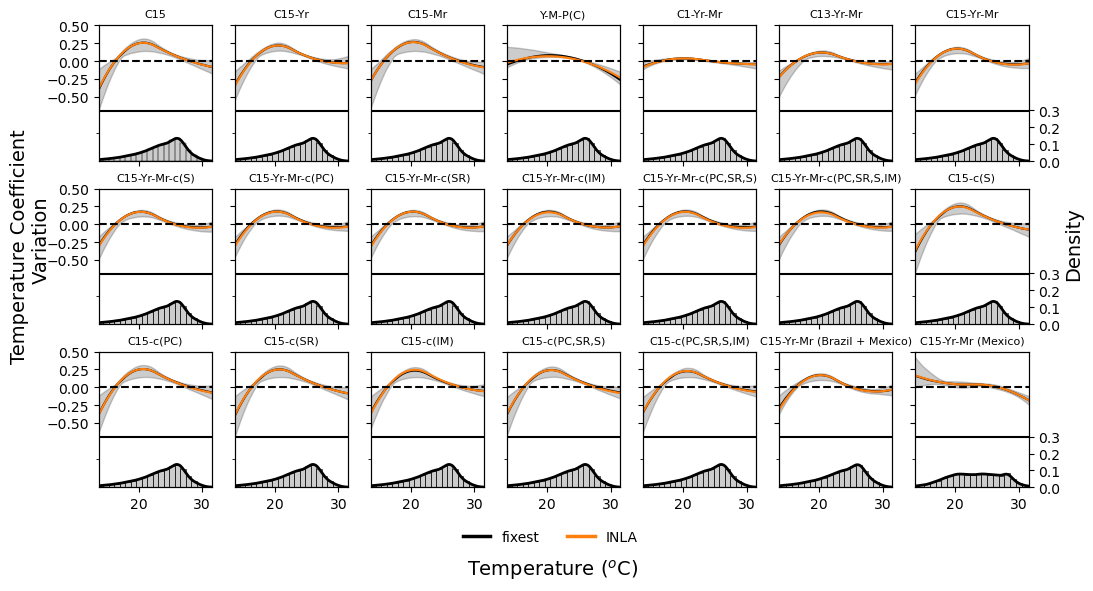

In [11]:
models = [
  'Climate(lag 1-5)',
  'Climate(lag 1-5) + Year|region',
  'Climate(lag 1-5) + Month|region',
  'Year + Month + P(Climate)',
  'Climate(lag 1) + Year|region + Month|region',
  'Climate(lag 1-3) + Year|region + Month|region',
  'Climate(lag 1-5) + Year|region + Month|region',
  'Climate(lag 1-5) + Year|region + Month|region + Socio',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases',
  'Climate(lag 1-5) + Year|region + Month|region + SeroRepla',
  'Climate(lag 1-5) + Year|region + Month|region + Immunity',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity',
  'Climate(lag 1-5) + Socio',
  'Climate(lag 1-5) + PriorCases',
  'Climate(lag 1-5) + SeroRepla',
  'Climate(lag 1-5) + Immunity',
  'Climate(lag 1-5) + PriorCases + SeroRepla + Socio',
  'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity',
  'Climate(lag 1-5) + Year|region + Month|region (Brazil + Mexico)',
  'Climate(lag 1-5) + Year|region + Month|region (Mexico only)' ,
]

model_ids = {
    'Climate(lag 1-5)': 'C15',
    'Climate(lag 1-5) + Month|region': 'C15-Mr',
    'Climate(lag 1-5) + PriorCases': 'C15-c(PC)',
    'Climate(lag 1-5) + SeroRepla': 'C15-c(SR)',
    'Climate(lag 1-5) + Socio': 'C15-c(S)',
    'Climate(lag 1-5) + Immunity': 'C15-c(IM)',
    'Year + Month': 'Y-M',
    'Month|region + PriorCases + SeroRepla + Socio + Immunity': 'Mr-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity': 'C15-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio': 'C15-c(PC,SR,S)',
    'Year + Month + P(Climate)': 'Y-M-P(C)',
    'Climate(lag 1-5) + Year|region': 'C15-Yr',
    'Climate(lag 1) + Year|region + Month|region': 'C1-Yr-Mr',
    'Climate(lag 1-3) + Year|region + Month|region': 'C13-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region': 'C15-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region + SeroRepla': 'C15-Yr-Mr-c(SR)',
    'Climate(lag 1-5) + Year|region + Month|region + Immunity': 'C15-Yr-Mr-c(IM)',
    'Climate(lag 1-5) + Year|region + Month|region + Socio': 'C15-Yr-Mr-c(S)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases': 'C15-Yr-Mr-c(PC)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 'C15-Yr-Mr-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio': 'C15-Yr-Mr-c(PC,SR,S)',
    'Climate(lag 1-5) + Year|region + Month|region (Brazil + Mexico)': 'C15-Yr-Mr (Brazil + Mexico)',
    'Climate(lag 1-5) + Year|region + Month|region (Mexico only)': 'C15-Yr-Mr (Mexico)',
}

dataframe_mapper = {
  'Climate(lag 1-5)': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Month|region': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Year + Month + P(Climate)': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1) + Year|region + Month|region': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-3) + Year|region + Month|region': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region + Socio': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region + SeroRepla': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region + Immunity': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Socio': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + PriorCases': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + SeroRepla': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Immunity': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + PriorCases + SeroRepla + Socio': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region (Brazil + Mexico)': 'data/model_input_mexico-peru-brazil_immunity.csv',
  'Climate(lag 1-5) + Year|region + Month|region (Mexico only)': 'data/model_input_mexico_immunity_city.csv',
}

fig, axarr = plt.subplots(3, 7, figsize=(12, 6), sharex=True, sharey=True)

for i, (model, ax) in enumerate(zip(models, axarr.flatten())):
    
    coefficients_model = pd.read_csv(f'../dengue/coefficients/{model}_coef_state_blockboot1000.csv')
    quantiles_model = calculate_temp_variation(coefficients_model, model)

    quantiles_model.plot(x='temp', y=0.5, ax=ax, color='k', legend=False)
    ax.fill_between(
        quantiles_model['temp'],
        quantiles_model[0.025],
        quantiles_model[0.975],
        color='k', alpha=0.2
    )


for i, (model, ax) in enumerate(zip(models, axarr.flatten())):
    model_tag = re.sub(r'[^A-Za-z0-9]+', '_', model)
    model_tag = re.sub(r'_+$', '', model_tag)  # strip trailing underscores

    ifiles = glob(f'/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/*_{model_tag}/*_{model_tag}_fe_samples_temp.csv')
    print(f'/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/*_{model_tag}/*_{model_tag}_fe_samples_temp.csv')
    print(ifiles)

    if len(ifiles) == 0:
        ifiles = glob(f'/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/*_{model_tag}/{model_tag}_fe_samples_temp.csv')
        
    if len(ifiles) > 0:
        ifile = ifiles[0]

        print(model)
        print(ifile)
        # try:
        #     if os.path.exists(ifile):
        coefficients_models = pd.read_csv(ifile)
        print(coefficients_models)
        quantiles_model = calculate_temp_variation(coefficients_models, model)

        quantiles_model.plot(x='temp', y=0.5, ax=ax, color='C1', legend=False)
        ax.fill_between(
            quantiles_model['temp'],
            quantiles_model[0.025],
            quantiles_model[0.975],
            color='C1', alpha=0.2
        )

            # try:
            #     coefficients_models = pd.read_csv(ifile)
            #     quantiles_model = calculate_temp_variation(coefficients_models, model)
    
            #     quantiles_model.plot(x='temp', y=0.5, ax=ax, color='C1', legend=False)
            #     ax.fill_between(
            #         quantiles_model['temp'],
            #         quantiles_model[0.025],
            #         quantiles_model[0.975],
            #         color='C1', alpha=0.2
            #     )
            # except Exception:
            #     pass

    df = pd.read_csv(dataframe_mapper[model])
    
    axt = ax.twinx()
    sns.histplot(df['mean_2m_air_temp_degree1'], bins=30, color='k', alpha=0.2, ax=axt, stat='density', zorder=0)
    sns.kdeplot(df['mean_2m_air_temp_degree1'], color='k', lw=2, ax=axt)
    
    ax.axhline(0, color='k', ls='--')
    ax.set_ylim([-1.4, 0.5])
    ax.set_title(model_ids[model], fontsize=8)
    ax.axhline(-0.7, color='k', ls='-')
    ax.set_yticks([-0.5, -0.25, 0.0, 0.25, 0.5])
    axt.set_ylim(0, 0.8)
    axt.set_ylabel('')
    ax.set_xlabel('')
    ax.set_xlim(df['mean_2m_air_temp_degree1'].quantile(0.01), df['mean_2m_air_temp_degree1'].quantile(0.99))

    if i not in [6, 13, 20]:
        axt.set_yticklabels([])
        axt.set_yticks([])
    else:
        axt.set_yticks([0.0, 0.1, 0.2, 0.3])
        
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = []

legend_elements.append(Line2D([0], [0], color='k', lw=2.5, label='fixest'))
legend_elements.append(Line2D([0], [0], color='C1', lw=2.5, label='INLA'))

# Place legend on the figure level or first axis
fig.legend(handles=legend_elements, frameon=False, ncol=4, bbox_to_anchor=(0.585, 0.06))

axarr[0, 0].text(-0.6, -0.6, 'Temperature Coefficient \n Variation', transform=axarr[0, 0].transAxes, va='center', ha='center', rotation=90, fontsize=14)
axarr[0, -1].text(1.4, -0.6, 'Density', transform=axarr[0, -1].transAxes, va='center', ha='center', rotation=90, fontsize=14)
axarr[2, 3].text(0.4, -0.6, r'Temperature ($^o$C)', transform=axarr[2, 3].transAxes, va='center', ha='center', fontsize=14)

plt.savefig('img/temp_coefficients.pdf', bbox_inches='tight')
#fig.delaxes(axarr[-1, -1])

In [12]:
def calculate_prec_variation(coefficients, model_name):

    prec = np.linspace(0, 1200, 400)

    prec_coef = []
    for i, coefs in coefficients.iterrows():

        if model_name == 'Climate(lag 1) + Year|region + Month|region':
            lag1_terms = prec * coefs.loc[f'total_precipitation_lag1']

            prec_variation = pd.DataFrame({
                'coef': lag1_terms,
                'prec': prec
            })

        elif model_name in ['Climate(lag 1-3) + Year|region + Month|region', 'Year + Month + P(Climate)']:
            lag1_terms = prec * coefs.loc[f'total_precipitation_lag1']
            lag2_terms = prec * coefs.loc[f'total_precipitation_lag2']
            lag3_terms = prec * coefs.loc[f'total_precipitation_lag3']

            prec_variation = pd.DataFrame({
                'coef': lag1_terms + lag2_terms + lag3_terms,
                'prec': prec
            })

        else:
            lag1_terms = prec * coefs.loc[f'total_precipitation_lag1']
            lag2_terms = prec * coefs.loc[f'total_precipitation_lag2']
            lag3_terms = prec * coefs.loc[f'total_precipitation_lag3']
            lag4_terms = prec * coefs.loc[f'total_precipitation_lag4']
            lag5_terms = prec * coefs.loc[f'total_precipitation_lag5']

            prec_variation = pd.DataFrame({
                'coef': lag1_terms + lag2_terms + lag3_terms + lag4_terms + lag5_terms,
                'prec': prec
            })
        
        prec_variation['model'] = i
        prec_coef.append(prec_variation)

    prec_coef = pd.concat(prec_coef)
    prec_coef_variation = prec_coef.groupby('model').apply(lambda x: x.set_index('prec')['coef'].diff()).reset_index().transpose()
    prec_coef_variation = prec_coef_variation.drop('model')

    quantiles = prec_coef_variation.quantile([0.025, 0.5, 0.975], axis=1).transpose().reset_index()
    quantiles['prec'] = quantiles['prec'].astype(float)

    return quantiles

/tmp/ipykernel_753/485480114.py:42: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prec_coef_variation = prec_coef.groupby('model').apply(lambda x: x.set_index('prec')['coef'].diff()).reset_index().transpose()
/tmp/ipykernel_753/2900432327.py:90: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(dataframe_mapper[model])
/tmp/ipykernel_753/485480114.py:42: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the group

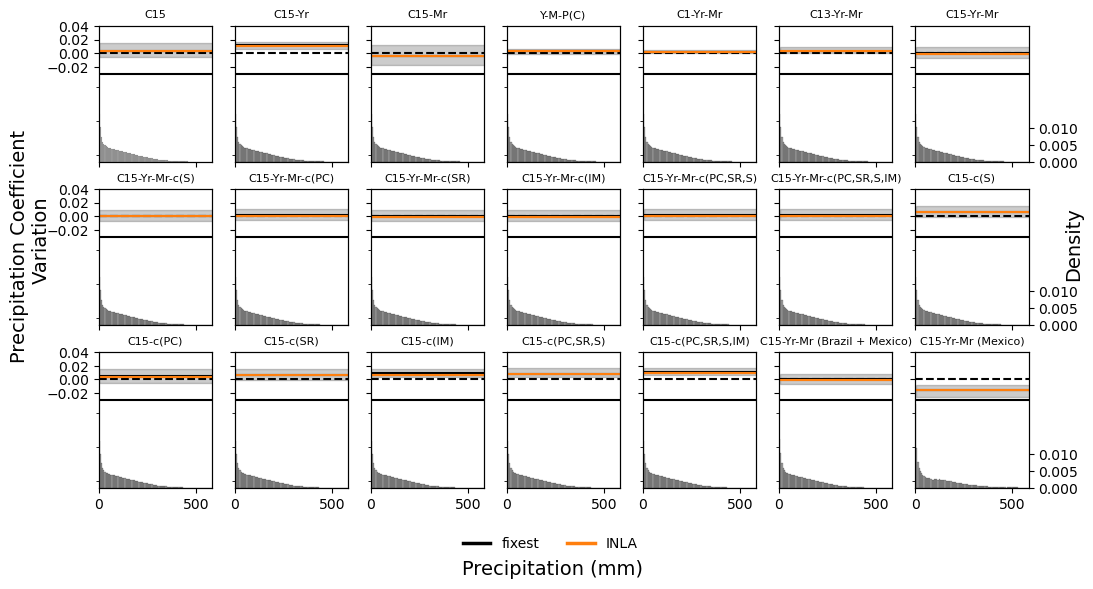

In [21]:
models = [
  'Climate(lag 1-5)',
  'Climate(lag 1-5) + Year|region',
  'Climate(lag 1-5) + Month|region',
  'Year + Month + P(Climate)',
  'Climate(lag 1) + Year|region + Month|region',
  'Climate(lag 1-3) + Year|region + Month|region',
  'Climate(lag 1-5) + Year|region + Month|region',
  'Climate(lag 1-5) + Year|region + Month|region + Socio',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases',
  'Climate(lag 1-5) + Year|region + Month|region + SeroRepla',
  'Climate(lag 1-5) + Year|region + Month|region + Immunity',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity',
  'Climate(lag 1-5) + Socio',
  'Climate(lag 1-5) + PriorCases',
  'Climate(lag 1-5) + SeroRepla',
  'Climate(lag 1-5) + Immunity',
  'Climate(lag 1-5) + PriorCases + SeroRepla + Socio',
  'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity',
  'Climate(lag 1-5) + Year|region + Month|region (Brazil + Mexico)',
  'Climate(lag 1-5) + Year|region + Month|region (Mexico only)' ,
]

model_ids = {
    'Climate(lag 1-5)': 'C15',
    'Climate(lag 1-5) + Month|region': 'C15-Mr',
    'Climate(lag 1-5) + PriorCases': 'C15-c(PC)',
    'Climate(lag 1-5) + SeroRepla': 'C15-c(SR)',
    'Climate(lag 1-5) + Socio': 'C15-c(S)',
    'Climate(lag 1-5) + Immunity': 'C15-c(IM)',
    'Year + Month': 'Y-M',
    'Month|region + PriorCases + SeroRepla + Socio + Immunity': 'Mr-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity': 'C15-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + PriorCases + SeroRepla + Socio': 'C15-c(PC,SR,S)',
    'Year + Month + P(Climate)': 'Y-M-P(C)',
    'Climate(lag 1-5) + Year|region': 'C15-Yr',
    'Climate(lag 1) + Year|region + Month|region': 'C1-Yr-Mr',
    'Climate(lag 1-3) + Year|region + Month|region': 'C13-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region': 'C15-Yr-Mr',
    'Climate(lag 1-5) + Year|region + Month|region + SeroRepla': 'C15-Yr-Mr-c(SR)',
    'Climate(lag 1-5) + Year|region + Month|region + Immunity': 'C15-Yr-Mr-c(IM)',
    'Climate(lag 1-5) + Year|region + Month|region + Socio': 'C15-Yr-Mr-c(S)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases': 'C15-Yr-Mr-c(PC)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 'C15-Yr-Mr-c(PC,SR,S,IM)',
    'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio': 'C15-Yr-Mr-c(PC,SR,S)',
    'Climate(lag 1-5) + Year|region + Month|region (Brazil + Mexico)': 'C15-Yr-Mr (Brazil + Mexico)',
    'Climate(lag 1-5) + Year|region + Month|region (Mexico only)': 'C15-Yr-Mr (Mexico)',
}

dataframe_mapper = {
  'Climate(lag 1-5)': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Month|region': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Year + Month + P(Climate)': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1) + Year|region + Month|region': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-3) + Year|region + Month|region': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region + Socio': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region + SeroRepla': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region + Immunity': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio + Immunity': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Socio': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + PriorCases': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + SeroRepla': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Immunity': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + PriorCases + SeroRepla + Socio + Immunity': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + PriorCases + SeroRepla + Socio': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region + PriorCases + SeroRepla + Socio': 'data/model_input_brazil_immunity_city_with_priorinf.csv',
  'Climate(lag 1-5) + Year|region + Month|region (Brazil + Mexico)': 'data/model_input_mexico-peru-brazil_immunity.csv',
  'Climate(lag 1-5) + Year|region + Month|region (Mexico only)': 'data/model_input_mexico_immunity_city.csv',
}

fig, axarr = plt.subplots(3, 7, figsize=(12, 6), sharex=True, sharey=True)

for i, (model, ax) in enumerate(zip(models, axarr.flatten())):
    
    coefficients_model = pd.read_csv(f'../dengue/coefficients/{model}_coef_state_blockboot1000.csv')
    quantiles_model = calculate_prec_variation(coefficients_model, model)

    quantiles_model.plot(x='prec', y=0.5, ax=ax, color='k', legend=False)
    ax.fill_between(
        quantiles_model['prec'],
        quantiles_model[0.025],
        quantiles_model[0.975],
        color='k', alpha=0.2
    )

    df = pd.read_csv(dataframe_mapper[model])
    
    axt = ax.twinx()
    sns.histplot(df['total_precipitation'], stat='density', color='gray', ax=axt, bins=np.linspace(0, 1200, 200))

    ax.axhline(0, color='k', ls='--')
    ax.set_xlim(df['total_precipitation'].min(), df['total_precipitation'].quantile(0.99))
    ax.set_ylim([-0.16, 0.02])
    #ax.set_ylim([-0.16, 0.02])
    ax.set_title(model_ids[model], fontsize=8)    
    ax.axhline(-0.03, color='k', ls='-')
    ax.set_yticks([-0.02, 0.0, 0.02, 0.04])
    axt.set_ylim([0, 0.04])
    axt.set_ylabel('')
    ax.set_xlabel('')

    if i not in [6, 13, 20]:
        axt.set_yticklabels([])
        axt.set_yticks([])
    else:
        axt.set_yticks([0, 0.005, 0.01])

for i, (model, ax) in enumerate(zip(models, axarr.flatten())):
    model_tag = re.sub(r'[^A-Za-z0-9]+', '_', model)
    model_tag = re.sub(r'_+$', '', model_tag)  # strip trailing underscores

    rescaled = [
        'Climate_lag_1_5_Year_region_Month_region_Immunity',
        'Climate_lag_1_5_Year_region_Month_region_PriorCases_SeroRepla_Socio',
        'Climate_lag_1_5_Year_region_Month_region_PriorCases_SeroRepla_Socio_Immunity',
        'Climate_lag_1_5_Socio',
        'Climate_lag_1_5_Year_region_Month_region_Socio',
        'Climate_lag_1_5_PriorCases_SeroRepla_Socio',
        'Climate_lag_1_5_PriorCases_SeroRepla_Socio_Immunity'
    ]

    ifiles = []
    if model_tag in rescaled:
        ifiles = glob(f'/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/*_{model_tag}/{model_tag}_fe_samples_precip_rescaled.csv')
        
    if len(ifiles) == 0:
        
        ifiles = glob(f'/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/*_{model_tag}/*_{model_tag}_fe_samples_precip.csv')

    # print(f'/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/*_{model_tag}/*_{model_tag}_fe_samples_precip.csv')
    # print(ifiles)

    if len(ifiles) == 0:
        ifiles = glob(f'/gws/ssde/j25a/cpdn_nonnerc/aaim/dengue_attribution/data/coefficients/inla/results/*_{model_tag}/{model_tag}_fe_samples_precip.csv')

    if len(ifiles) > 0:
        ifile = ifiles[0]
        if os.path.exists(ifile):
            try:
                coefficients_models = pd.read_csv(ifile)
                quantiles_model = calculate_prec_variation(coefficients_models, model)
    
                quantiles_model.plot(x='prec', y=0.5, ax=ax, color='C1', legend=False)
                ax.fill_between(
                    quantiles_model['prec'],
                    quantiles_model[0.025],
                    quantiles_model[0.975],
                    color='C1', alpha=0.2
                )
            except Exception:
                pass


    ax.set_xlabel('')


from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = []

legend_elements.append(Line2D([0], [0], color='k', lw=2.5, label='fixest'))
legend_elements.append(Line2D([0], [0], color='C1', lw=2.5, label='INLA'))

# Place legend on the figure level or first axis
fig.legend(handles=legend_elements, frameon=False, ncol=4, bbox_to_anchor=(0.585, 0.05))

axarr[0, 0].text(-0.6, -0.6, 'Precipitation Coefficient \n Variation', transform=axarr[0, 0].transAxes, va='center', ha='center', rotation=90, fontsize=14)
axarr[0, -1].text(1.4, -0.6, 'Density', transform=axarr[0, -1].transAxes, va='center', ha='center', rotation=90, fontsize=14)
axarr[2, 3].text(0.4, -0.6, r'Precipitation (mm)', transform=axarr[2, 3].transAxes, va='center', ha='center', fontsize=14)

plt.savefig('img/precip_coefficients.pdf', bbox_inches='tight')

#fig.delaxes(axarr[-1, -1])